In [ ]:
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/dsrscientist/dataset1/master/heart_disease.csv"

columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol',
    'fbs', 'restecg', 'thalach', 'exang', 'oldpeak',
    'slope', 'ca', 'thal', 'target'
]

df = pd.read_csv(url, names=columns, na_values='?', header=0)

: 

In [2]:
print(df.shape)

(303, 14)


In [3]:
print(df.dtypes)

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


In [4]:
print(df.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  


LOAD AND UNDERSTAND

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
None


In [6]:
print(df.describe())

              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.366337    0.683168    0.966997  131.623762  246.264026    0.148515   
std      9.082101    0.466011    1.032052   17.538143   51.830751    0.356198   
min     29.000000    0.000000    0.000000   94.000000  126.000000    0.000000   
25%     47.500000    0.000000    0.000000  120.000000  211.000000    0.000000   
50%     55.000000    1.000000    1.000000  130.000000  240.000000    0.000000   
75%     61.000000    1.000000    2.000000  140.000000  274.500000    0.000000   
max     77.000000    1.000000    3.000000  200.000000  564.000000    1.000000   

          restecg     thalach       exang     oldpeak       slope          ca  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean     0.528053  149.646865    0.326733    1.039604    1.399340    0.729373   
std      0.525860   22.9051

In [7]:
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [8]:
#Binarize target: 0 = no disease, 1 = disease
df['target'] = (df['target'] > 0).astype(int)

In [9]:
print("\nDisease Distribution: ")
print(df['target'].value_counts())
print(df['target'].value_counts(normalize=True).round(2))


Disease Distribution: 
target
1    165
0    138
Name: count, dtype: int64
target
1    0.54
0    0.46
Name: proportion, dtype: float64


CLEAN & PREPROCESS

In [10]:
#Drop rows with missing values (only 6 rows affected)
df.dropna(inplace=True)
print("Clean shape: ",df.shape)

Clean shape:  (303, 14)


In [11]:
#Fix Data Types
df['ca'] = df['ca'].astype(int)
df['thal'] = df['thal'].astype(int)

In [12]:
#Label encode categorial columns for readibility
cp_labels = {0: 'Typical angina', 1: 'Atypical angina',
             2: 'Non-anginal', 3: 'Asymptomatic'}
df['cp_label'] = df['cp'].map(cp_labels)

In [13]:
#Seperate Features and target
X = df.drop(['target','cp_label'], axis=1)
y = df['target']

Exploratory Data Analysis(EDA)

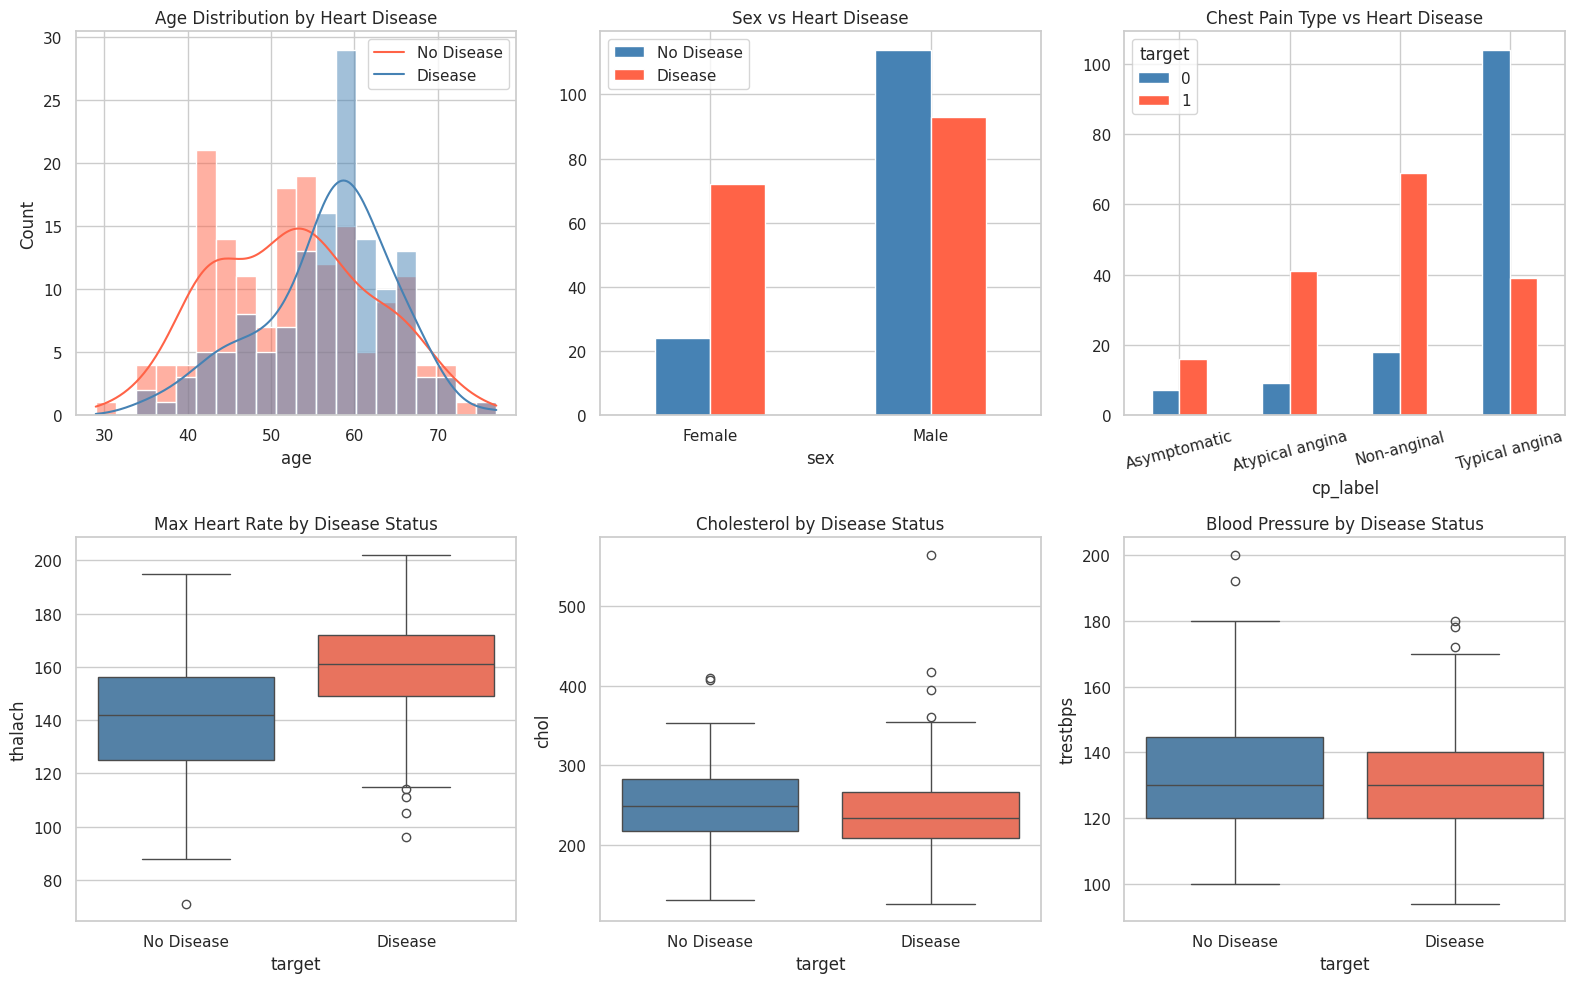

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Age distribution by disease status
sns.histplot(data=df, x='age', hue='target', bins=20,
             ax=axes[0,0], kde=True, palette=['steelblue','tomato'])
axes[0,0].set_title('Age Distribution by Heart Disease')
axes[0,0].legend(['No Disease', 'Disease'])

# 2. Sex vs disease
sex_counts = df.groupby(['sex', 'target']).size().unstack()
sex_counts.plot(kind='bar', ax=axes[0,1], color=['steelblue','tomato'], rot=0)
axes[0,1].set_title('Sex vs Heart Disease')
axes[0,1].set_xticklabels(['Female', 'Male'])
axes[0,1].legend(['No Disease', 'Disease'])

# 3. Chest pain type vs disease
cp_counts = df.groupby(['cp_label', 'target']).size().unstack()
cp_counts.plot(kind='bar', ax=axes[0,2], color=['steelblue','tomato'], rot=15)
axes[0,2].set_title('Chest Pain Type vs Heart Disease')

# --- FIX 1: Add hue= and legend=False to all boxplots ---
# --- FIX 2: Use ax.set_xticks() before set_xticklabels() ---

# 4. Max heart rate (thalach)
sns.boxplot(data=df, x='target', y='thalach', ax=axes[1,0],
            hue='target', palette=['steelblue','tomato'], legend=False)
axes[1,0].set_title('Max Heart Rate by Disease Status')
axes[1,0].set_xticks([0, 1])
axes[1,0].set_xticklabels(['No Disease', 'Disease'])

# 5. Cholesterol
sns.boxplot(data=df, x='target', y='chol', ax=axes[1,1],
            hue='target', palette=['steelblue','tomato'], legend=False)
axes[1,1].set_title('Cholesterol by Disease Status')
axes[1,1].set_xticks([0, 1])
axes[1,1].set_xticklabels(['No Disease', 'Disease'])

# 6. Resting blood pressure
sns.boxplot(data=df, x='target', y='trestbps', ax=axes[1,2],
            hue='target', palette=['steelblue','tomato'], legend=False)
axes[1,2].set_title('Blood Pressure by Disease Status')
axes[1,2].set_xticks([0, 1])
axes[1,2].set_xticklabels(['No Disease', 'Disease'])

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150)
plt.show()

Statistical Analysis

In [15]:
from scipy import stats

print("=== Key Statistucal Findings ===\n")

#T-Test: is age significantly different between groups
no_disease = df[df['target'] == 0]['age']
disease = df[df['target'] == 1]['age']
t_stat, p_val, = stats.ttest_ind(no_disease, disease)
print(f"Age- No disease mean: {no_disease.mean():.1f}, Disease mean: {disease.mean():.1f}")
print(f"T-test p-value: {p_val:.4f} -> {'Significant' if p_val < 0.05 else 'Non-Significant'} \n")

#Same for max heart rate
thal_nd = df[df['target'] == 0]['thalach']
thal_d = df[df['target'] == 1]['thalach']
t_thal, p_thal = stats.ttest_ind(thal_nd, thal_d)
print(f"Max HR-No disease mean: {thal_nd.mean():.1f}, Disease mean: {thal_d.mean():.1f}")
print(f"T-Statistic: {t_thal:.4f}, p-value {p_thal:4f} -> {'Significant' if p_thal < 0.05 else 'Non-Significant'}\n")

#T-Test: cholesterol
chol_nd = df[df['target'] == 0]['chol']
chol_d = df[df['target'] == 1]['chol']
t_chol, p_chol = stats.ttest_ind(chol_nd, chol_d)
print(f"Cholesterol - No disease mean: {chol_nd.mean():.1f}, Disease mean: {chol_d.mean():.1f}")
print(f"T-statistic: {t_chol:.4f}, p-value {'Significant' if p_chol < 0.05 else 'Non-significant'}\n")

#Chi-Square: Sex vs Disease
contingency = pd.crosstab(df['sex'], df['target'])
chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)
print(f"Sex vs Disease - Chi2: {chi2:.2f}, p-value: {p_chi:.4f}")
print(f"Result: {'Significant association' if p_chi < 0.05 else 'No association'}\n")

=== Key Statistucal Findings ===

Age- No disease mean: 56.6, Disease mean: 52.5
T-test p-value: 0.0001 -> Significant 

Max HR-No disease mean: 139.1, Disease mean: 158.5
T-Statistic: -8.0697, p-value 0.000000 -> Significant

Cholesterol - No disease mean: 251.1, Disease mean: 242.2
T-statistic: 1.4842, p-value Non-significant

Sex vs Disease - Chi2: 22.72, p-value: 0.0000
Result: Significant association



PHASE 5 - CORRELATION & FEATURE IMPORTANCE

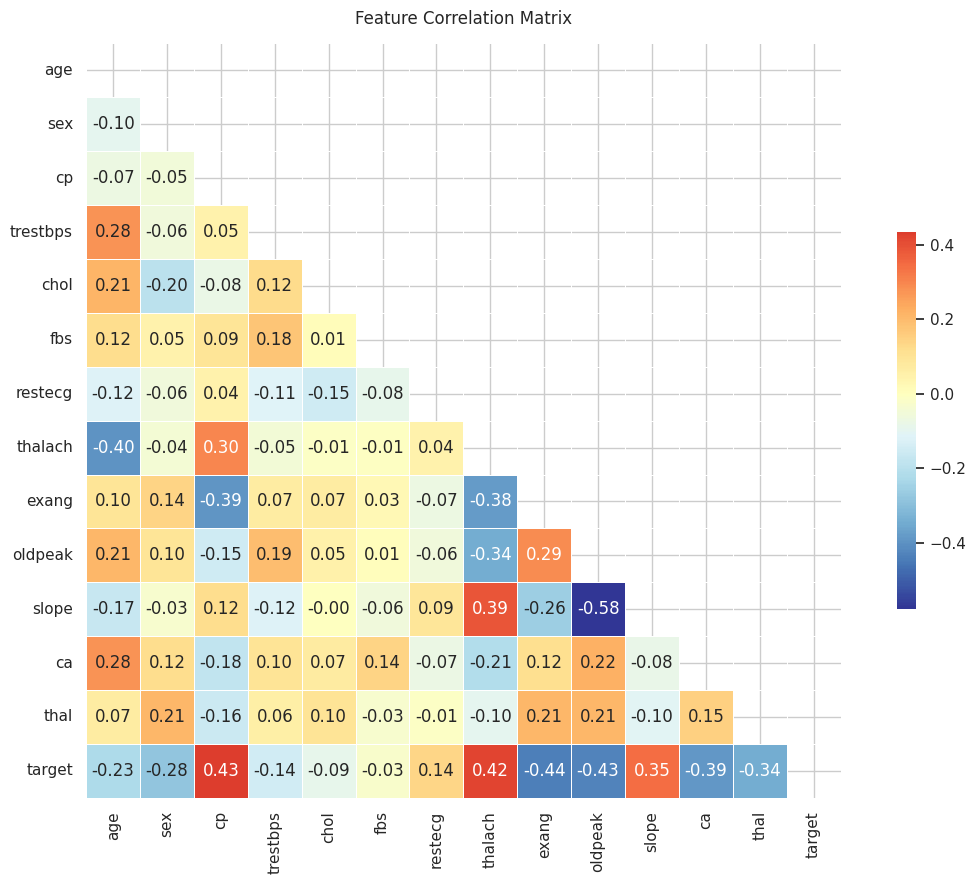


Correlation with Heart Disease (sorted):
exang      -0.437
oldpeak    -0.431
ca         -0.392
thal       -0.344
sex        -0.281
age        -0.225
trestbps   -0.145
chol       -0.085
fbs        -0.028
restecg     0.137
slope       0.346
thalach     0.422
cp          0.434
Name: target, dtype: float64


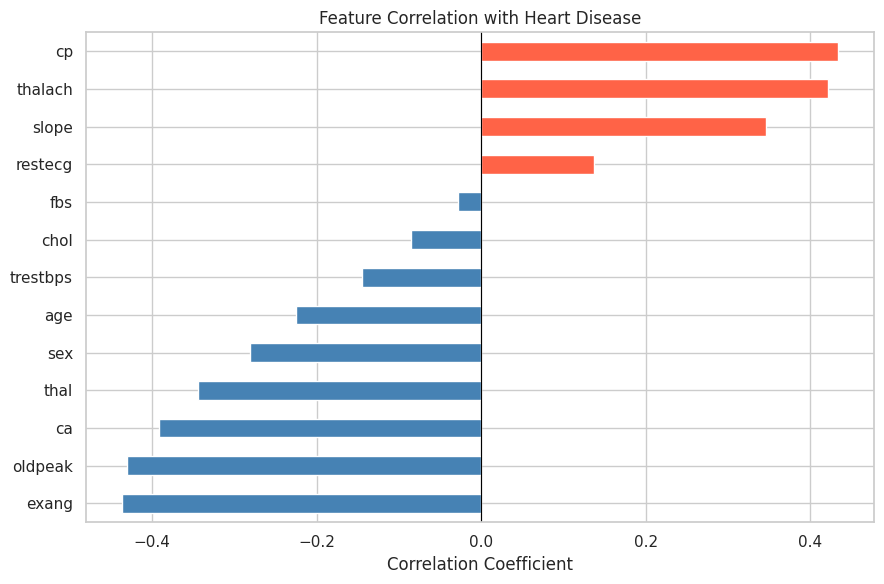

In [16]:
from jax import transfer_guard_device_to_device
from jax._src.xla_bridge import discover_pjrt_plugins
#Correlation Heatmap
plt.figure(figsize=(12,9))
corr = df[X.columns.tolist() + ['target']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    annot = True,
    fmt = '.2f',
    cmap = 'RdYlBu_r',
    center = 0,
    mask = mask,
    square = True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.5}
)
plt.title('Feature Correlation Matrix', pad = 14)
plt.tight_layout()
plt.savefig('Correlation_heatmap.png', dpi = 150, bbox_inches='tight')
plt.show()

# Top correlations with target
target_corr = corr['target'].drop('target').sort_values()
print("\nCorrelation with Heart Disease (sorted):")
print(target_corr.round(3))

plt.figure(figsize=(9, 6))
colors = ['tomato' if v > 0 else 'steelblue' for v in target_corr]
target_corr.plot(kind = 'barh', color = colors)
plt.title('Feature Correlation with Heart Disease')
plt.xlabel('Correlation Coefficient')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('target_correlation.png',dpi=150, bbox_inches='tight')
plt.show()

PHASE 6: PREDICTION MODEL

Logistic Regression
              precision    recall  f1-score   support

 No Diseases       0.86      0.68      0.76        28
     Disease       0.77      0.91      0.83        33

    accuracy                           0.80        61
   macro avg       0.82      0.79      0.80        61
weighted avg       0.81      0.80      0.80        61

ROC-AUC: 0.869



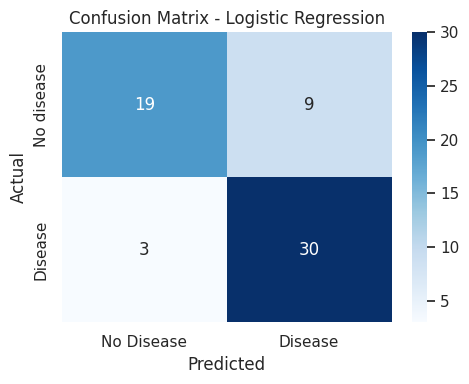

Random Forest
              precision    recall  f1-score   support

  No disease       0.95      0.68      0.79        28
     Disease       0.78      0.97      0.86        33

    accuracy                           0.84        61
   macro avg       0.87      0.82      0.83        61
weighted avg       0.86      0.84      0.83        61

ROC-AUC: 0.909



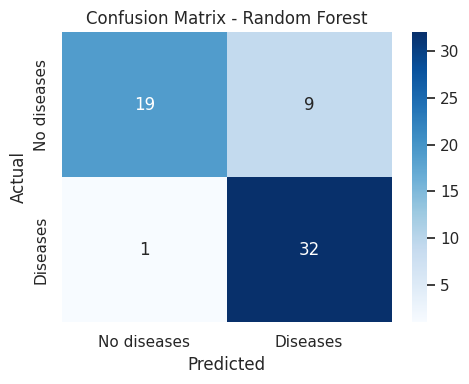

In [17]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve)
from sklearn.pipeline import Pipeline

#Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#Scale Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Model 1: Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression")
print(classification_report(y_test, lr_pred, target_names=['No Diseases', 'Disease']))
print(f"ROC-AUC: {roc_auc_score(y_test, lr_proba):.3f}\n")

#Confusion Matrix - Logistic Regression
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt='d',
            cmap='Blues', xticklabels=['No Disease', 'Disease'],
            yticklabels=['No disease', 'Disease'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('cm_logistic.png', dpi=150, bbox_inches='tight')
plt.show()

#Model 2: Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)
rf_proba = rf.predict_proba(X_test_scaled)[:,1]

print("Random Forest")
print(classification_report(y_test, rf_pred, target_names=['No disease','Disease']))
print(f"ROC-AUC: {roc_auc_score(y_test, rf_proba):.3f}\n")

#Confusion Matrix - Random Forest
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, rf_pred),annot=True, fmt='d',
            cmap='Blues', xticklabels=['No diseases', 'Diseases'],
            yticklabels=['No diseases', 'Diseases'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('cm_random.png', dpi=150, bbox_inches='tight')
plt.show()

Logistic Regression 5-fold CV: 0.835 +- 0.041
Random Forest 5-fold CV: 0.838 +- 0.029


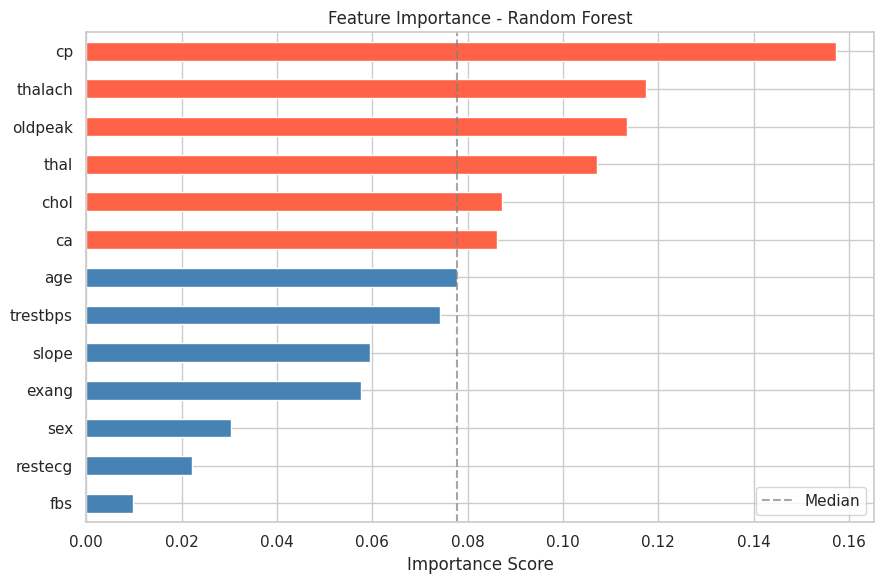

In [18]:
#Cross Validation
#Fixed: pass unsacled X with a pipeline to avoid data leakage in CV
lr_pipe = Pipeline([('scaler', StandardScaler()),
                    ('model', LogisticRegression(max_iter=1000, random_state=42))])
rf_pipe = Pipeline([('scaler', StandardScaler()),
                    ('model', RandomForestClassifier(n_estimators=100, random_state=42))])
cv_lr = cross_val_score(lr_pipe, X, y, cv=5, scoring='accuracy')
cv_rf = cross_val_score(rf_pipe, X, y, cv=5, scoring='accuracy')

print(f"Logistic Regression 5-fold CV: {cv_lr.mean():.3f} +- {cv_lr.std():.3f}")
print(f"Random Forest 5-fold CV: {cv_rf.mean():.3f} +- {cv_rf.std():.3f}")

# Feature Importance (Random Forest)
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(9, 6))
colors = ['tomato' if v > feat_imp.median() else 'steelblue' for v in feat_imp]
feat_imp.plot(kind='barh', color=colors)
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.axvline(feat_imp.median(), color='gray', linestyle='--', alpha=0.7, label='Median')
plt.legend()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

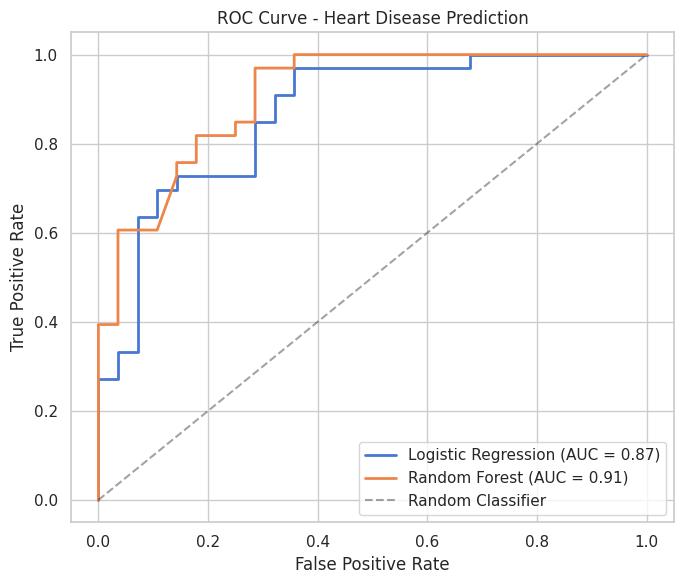


 All phases complete. Outputs saved to current directory


In [19]:
#ROC Curve
fig, ax= plt.subplots(figsize=(7, 6))
for name, proba in [('Logistic Regression', lr_proba), ('Random Forest', rf_proba)]:
  fpr, tpr, _ = roc_curve(y_test, proba)
  auc = roc_auc_score(y_test, proba)
  ax.plot(fpr, tpr, label = f'{name} (AUC = {auc:.2f})', linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label = 'Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve - Heart Disease Prediction')
ax.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n All phases complete. Outputs saved to current directory")